# Graph Neural Network — Plank Form Classification
### PyTorch Geometric (PyG) — Full End-to-End Trained GNN

This notebook trains a **proper GNN** where the graph convolutional weights are learned via backpropagation — not randomly initialized.

**Architecture:** 3-layer GCN → Flatten → MLP head → 3-class classifier

**Labels:**
| Label | Meaning |
|---|---|
| `C` | Correct plank form |
| `H` | High lower back (raised too high) |
| `L` | Low lower back (dropped too low) |

**Key differences from the bicep curl model:**
- **17 nodes** instead of 9 — includes knees, ankles, heels, foot indices
- **3 classes** instead of 2 — multiclass classification
- **Richer skeleton graph** — 16 anatomical edges covering the full body chain
- Evaluation uses **macro-averaged** metrics and a multiclass confusion matrix

---
### Setup (run once)
```bash
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
pip install torch_geometric
```
Or on **Google Colab**: `!pip install torch_geometric`

## 1. Imports

In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx
import pickle
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
from sklearn.decomposition import PCA

# ── Config ─────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PALETTE = ['#667eea', '#764ba2', '#f093fb']
C1, C2, C3, C4 = '#667eea', '#f093fb', '#4facfe', '#43e97b'

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'axes.spines.top': False, 'axes.spines.right': False,
})

print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
print(f'CUDA    : {torch.cuda.is_available()}')

PyTorch : 2.10.0+cu128
Device  : cuda
CUDA    : True


## 2. Load & Split Data

In [5]:
# ── Load pre-split datasets ────────────────────────────────────────────────
# train.csv and test.csv come from different recording sessions

train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

# # If you only have a single CSV, split it:
# df = pd.read_csv('data.csv')
# train_df, test_df = train_test_split(df, test_size=0.2,
#                                       random_state=RANDOM_STATE,
#                                       stratify=df['label'])

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

FEATURE_COLS = [c for c in train_df.columns if c != 'label']

print('┌─────────────────────────────────────────────┐')
print(f'│  Train samples   : {len(train_df):>7,}               │')
print(f'│  Test  samples   : {len(test_df):>7,}               │')
print(f'│  Feature columns : {len(FEATURE_COLS):>7}               │')
print(f'│  Nodes per graph :      17               │')
print(f'│  Features/node   :       4  (x,y,z,v)   │')
print(f'│  Classes         :       3  (C, H, L)    │')
print('└─────────────────────────────────────────────┘')
print()
print('Train label counts:')
print(train_df['label'].value_counts().to_string())
print('\nTest label counts:')
print(test_df['label'].value_counts().to_string())

┌─────────────────────────────────────────────┐
│  Train samples   :  28,520               │
│  Test  samples   :     710               │
│  Feature columns :      68               │
│  Nodes per graph :      17               │
│  Features/node   :       4  (x,y,z,v)   │
│  Classes         :       3  (C, H, L)    │
└─────────────────────────────────────────────┘

Train label counts:
label
C    9904
L    9546
H    9070

Test label counts:
label
H    241
L    235
C    234


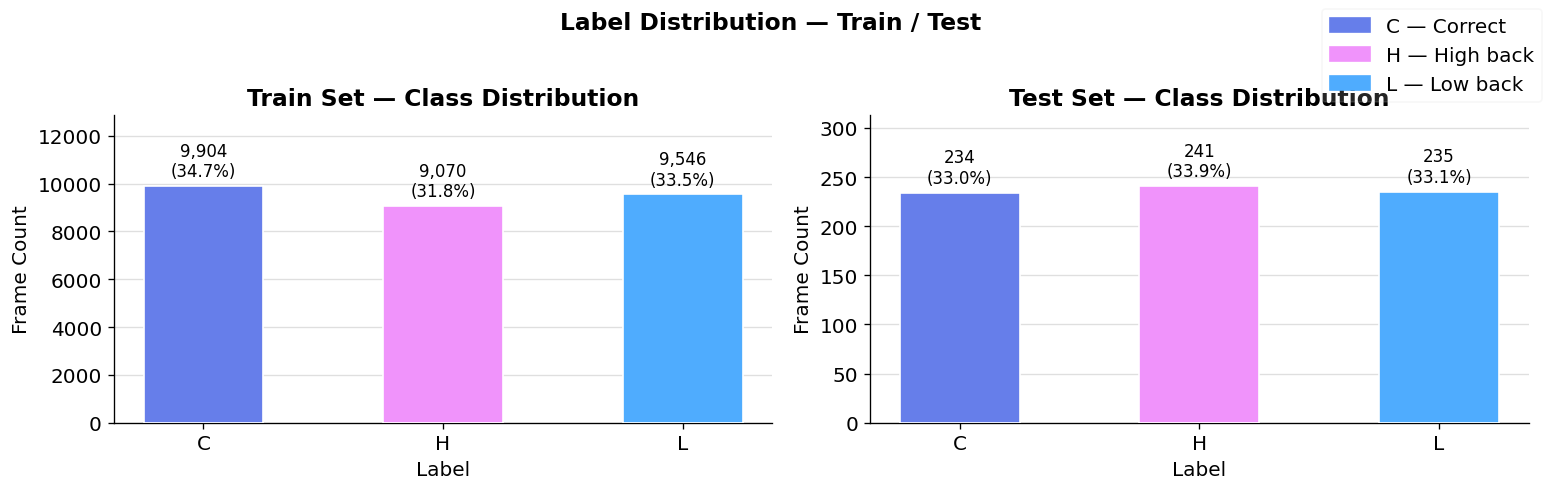

In [6]:
# ── Class distribution plot ────────────────────────────────────────────────
CLASS_COLORS = {'C': C1, 'H': C2, 'L': C3}
CLASS_LABELS = {'C': 'C — Correct', 'H': 'H — High back', 'L': 'L — Low back'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (df_plot, title) in zip(axes, [(train_df, 'Train Set'), (test_df, 'Test Set')]):
    counts = df_plot['label'].value_counts().sort_index()
    colors = [CLASS_COLORS[l] for l in counts.index]
    bars   = ax.bar(counts.index, counts.values, color=colors,
                    edgecolor='white', width=0.5, zorder=3)
    ax.set_title(f'{title} — Class Distribution', fontweight='bold')
    ax.set_xlabel('Label')
    ax.set_ylabel('Frame Count')
    ax.grid(axis='y', alpha=0.4, zorder=0)
    ax.set_ylim(0, counts.max() * 1.3)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + counts.max()*0.04,
                f'{val:,}\n({val/len(df_plot)*100:.1f}%)',
                ha='center', fontsize=10)

legend_items = [mpatches.Patch(color=v, label=CLASS_LABELS[k])
                for k, v in CLASS_COLORS.items()]
fig.legend(handles=legend_items, loc='upper right', framealpha=0.15)
plt.suptitle('Label Distribution — Train / Test', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_01_class_distribution.png', bbox_inches='tight')
plt.show()

## 3. Define the Pose Graph

Each frame → a graph where:
- **Nodes** = 17 body landmarks (full-body chain including legs and feet)
- **Edges** = anatomical kinematic connections (16 undirected, 32 directed)
- **Node features** = `[x, y, z, visibility]`

The plank graph is richer than the bicep graph because the lower body — hips, knees, ankles, heels — is critical for detecting back position errors.

In [7]:
# ── Landmark order — taken directly from plank.py init_important_landmarks() ─
# LEFT before RIGHT throughout (matches the plank source exactly)
LANDMARKS = [
    'nose',
    'left_shoulder',    'right_shoulder',
    'left_elbow',       'right_elbow',
    'left_wrist',       'right_wrist',
    'left_hip',         'right_hip',
    'left_knee',        'right_knee',
    'left_ankle',       'right_ankle',
    'left_heel',        'right_heel',
    'left_foot_index',  'right_foot_index',
]
N_NODES = len(LANDMARKS)   # 17
N_FEATS = 4                # x, y, z, visibility

# Anatomical edges — full-body kinematic chain
SKELETON_EDGES = [
    # Head → torso
    ('nose',           'left_shoulder'),
    ('nose',           'right_shoulder'),
    # Collar
    ('left_shoulder',  'right_shoulder'),
    # Arms
    ('left_shoulder',  'left_elbow'),
    ('right_shoulder', 'right_elbow'),
    ('left_elbow',     'left_wrist'),
    ('right_elbow',    'right_wrist'),
    # Trunk
    ('left_shoulder',  'left_hip'),
    ('right_shoulder', 'right_hip'),
    ('left_hip',       'right_hip'),
    # Legs
    ('left_hip',       'left_knee'),
    ('right_hip',      'right_knee'),
    ('left_knee',      'left_ankle'),
    ('right_knee',     'right_ankle'),
    # Feet
    ('left_ankle',     'left_heel'),
    ('right_ankle',    'right_heel'),
    ('left_ankle',     'left_foot_index'),
    ('right_ankle',    'right_foot_index'),
]

node_to_idx = {n: i for i, n in enumerate(LANDMARKS)}

# Build bidirectional edge_index
src, dst = [], []
for u, v in SKELETON_EDGES:
    i, j = node_to_idx[u], node_to_idx[v]
    src += [i, j]
    dst += [j, i]
EDGE_INDEX = torch.tensor([src, dst], dtype=torch.long)

print(f'Nodes : {N_NODES}')
print(f'Edges : {len(SKELETON_EDGES)} undirected → {EDGE_INDEX.shape[1]} directed')
print(f'edge_index shape : {EDGE_INDEX.shape}')
print('\nLandmark → node index:')
for name, idx in node_to_idx.items():
    print(f'  {idx:2d}: {name}')

Nodes : 17
Edges : 18 undirected → 36 directed
edge_index shape : torch.Size([2, 36])

Landmark → node index:
   0: nose
   1: left_shoulder
   2: right_shoulder
   3: left_elbow
   4: right_elbow
   5: left_wrist
   6: right_wrist
   7: left_hip
   8: right_hip
   9: left_knee
  10: right_knee
  11: left_ankle
  12: right_ankle
  13: left_heel
  14: right_heel
  15: left_foot_index
  16: right_foot_index


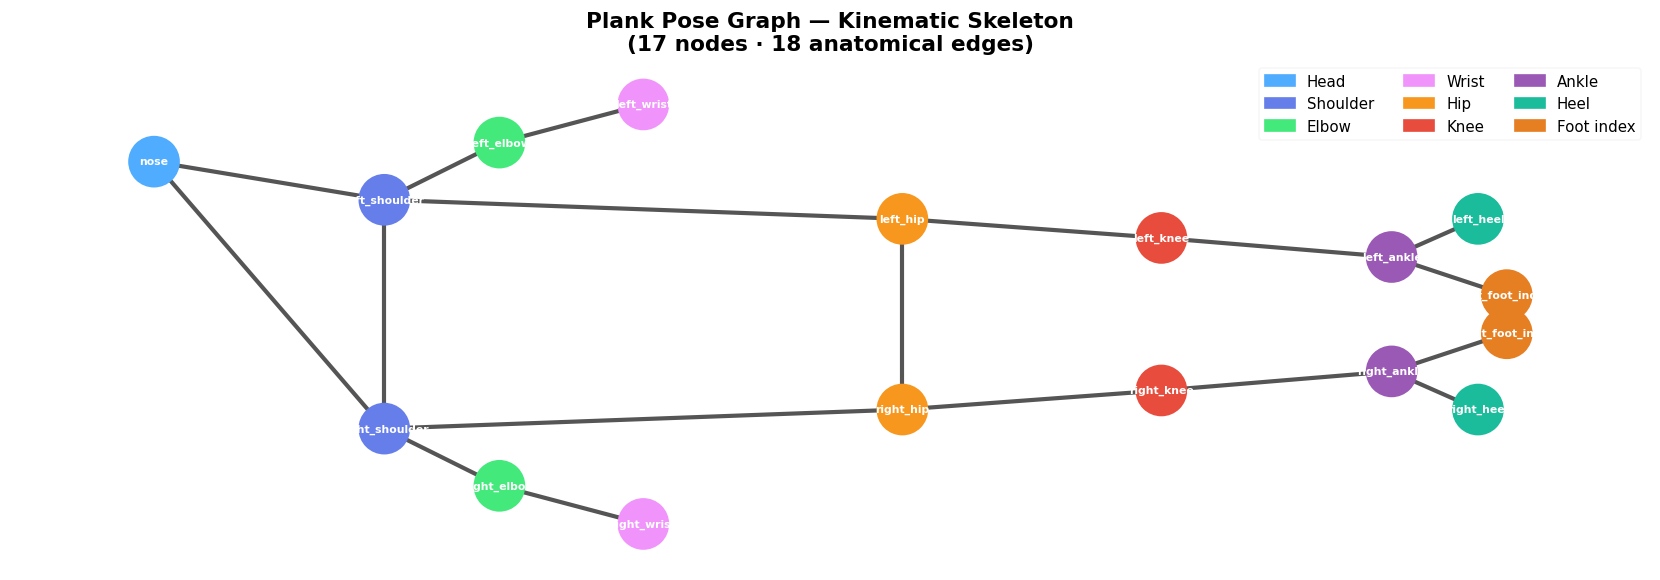

In [8]:
# ── Visualise the skeleton graph ───────────────────────────────────────────
G = nx.Graph()
G.add_nodes_from(LANDMARKS)
G.add_edges_from(SKELETON_EDGES)

# Anatomical layout — horizontal plank position
pos = {
    'nose':             (-2.2,  0.8),
    'left_shoulder':    (-1.4,  0.6),  'right_shoulder':   (-1.4, -0.6),
    'left_elbow':       (-1.0,  0.9),  'right_elbow':      (-1.0, -0.9),
    'left_wrist':       (-0.5,  1.1),  'right_wrist':      (-0.5, -1.1),
    'left_hip':         ( 0.4,  0.5),  'right_hip':        ( 0.4, -0.5),
    'left_knee':        ( 1.3,  0.4),  'right_knee':       ( 1.3, -0.4),
    'left_ankle':       ( 2.1,  0.3),  'right_ankle':      ( 2.1, -0.3),
    'left_heel':        ( 2.4,  0.5),  'right_heel':       ( 2.4, -0.5),
    'left_foot_index':  ( 2.5,  0.1),  'right_foot_index': ( 2.5, -0.1),
}

node_color_map = {
    'nose'           : C3,
    'left_shoulder'  : C1,  'right_shoulder'  : C1,
    'left_elbow'     : C4,  'right_elbow'     : C4,
    'left_wrist'     : C2,  'right_wrist'     : C2,
    'left_hip'       : '#f7971e', 'right_hip'       : '#f7971e',
    'left_knee'      : '#e74c3c', 'right_knee'      : '#e74c3c',
    'left_ankle'     : '#9b59b6', 'right_ankle'     : '#9b59b6',
    'left_heel'      : '#1abc9c', 'right_heel'      : '#1abc9c',
    'left_foot_index': '#e67e22', 'right_foot_index': '#e67e22',
}
node_colors = [node_color_map[n] for n in LANDMARKS]

fig, ax = plt.subplots(figsize=(14, 5))
nx.draw_networkx_edges(G, pos, width=2.5, edge_color='#555', ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=900, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=6.5, font_color='white',
                         font_weight='bold', ax=ax)
legend_items = [
    mpatches.Patch(color=C3,        label='Head'),
    mpatches.Patch(color=C1,        label='Shoulder'),
    mpatches.Patch(color=C4,        label='Elbow'),
    mpatches.Patch(color=C2,        label='Wrist'),
    mpatches.Patch(color='#f7971e', label='Hip'),
    mpatches.Patch(color='#e74c3c', label='Knee'),
    mpatches.Patch(color='#9b59b6', label='Ankle'),
    mpatches.Patch(color='#1abc9c', label='Heel'),
    mpatches.Patch(color='#e67e22', label='Foot index'),
]
ax.legend(handles=legend_items, loc='upper right', fontsize=9,
          framealpha=0.15, ncol=3)
ax.set_title('Plank Pose Graph — Kinematic Skeleton\n'
             f'(17 nodes · {len(SKELETON_EDGES)} anatomical edges)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('fig_02_pose_graph.png', bbox_inches='tight')
plt.show()

## 4. Standardise Features — Train & Test Separately

**Rule:** Scaler is `fit` only on train. Test is only `transform`-ed — no data leakage.

For plank we apply the same camera-invariant normalisation as the bicep model:
1. **Subtract torso centre** — removes camera position offset
2. **Divide by torso size** (shoulder-to-hip distance) — removes camera distance and body height variation

In [9]:
def normalize_pose(df):
    """
    Camera-invariant normalisation:
    1. Subtract torso centre  → removes camera position offset
    2. Divide by torso size   → removes camera distance / person height
    Operates on all x/y/z columns; visibility is left unchanged.
    """
    df = df.copy()

    centre_x = (df['left_shoulder_x'] + df['right_shoulder_x'] +
                 df['left_hip_x']      + df['right_hip_x']) / 4
    centre_y = (df['left_shoulder_y'] + df['right_shoulder_y'] +
                 df['left_hip_y']      + df['right_hip_y']) / 4

    shoulder_mid_x = (df['left_shoulder_x'] + df['right_shoulder_x']) / 2
    shoulder_mid_y = (df['left_shoulder_y'] + df['right_shoulder_y']) / 2
    hip_mid_x      = (df['left_hip_x']      + df['right_hip_x'])      / 2
    hip_mid_y      = (df['left_hip_y']      + df['right_hip_y'])      / 2

    torso_size = np.sqrt(
        (shoulder_mid_x - hip_mid_x) ** 2 +
        (shoulder_mid_y - hip_mid_y) ** 2
    ) + 1e-6

    for lm in LANDMARKS:
        df[f'{lm}_x'] = (df[f'{lm}_x'] - centre_x) / torso_size
        df[f'{lm}_y'] = (df[f'{lm}_y'] - centre_y) / torso_size
        df[f'{lm}_z'] =  df[f'{lm}_z']              / torso_size
        # visibility left as-is

    return df


# Apply normalisation BEFORE scaling
train_norm = normalize_pose(train_df)
test_norm  = normalize_pose(test_df)

# ── Label encoding: C=0, H=1, L=2 ────────────────────────────────────────
le = LabelEncoder()
y_train_np = le.fit_transform(train_norm['label'].values)
y_test_np  = le.transform(test_norm['label'].values)
N_CLASSES  = len(le.classes_)
print('Label encoding:', dict(zip(le.classes_, le.transform(le.classes_))))
print('Classes:', le.classes_.tolist(), '| N_CLASSES:', N_CLASSES)

# ── Standardise SEPARATELY ────────────────────────────────────────────────
scaler     = StandardScaler()
X_train_np = scaler.fit_transform(train_norm[FEATURE_COLS].values)  # fit + transform
X_test_np  = scaler.transform(test_norm[FEATURE_COLS].values)       # transform only

print(f'\nTrain — mean: {X_train_np.mean():+.5f} | std: {X_train_np.std():.5f}  (≈0 and ≈1 ✓)')
print(f'Test  — mean: {X_test_np.mean():+.5f} | std: {X_test_np.std():.5f}')

Label encoding: {'C': np.int64(0), 'H': np.int64(1), 'L': np.int64(2)}
Classes: ['C', 'H', 'L'] | N_CLASSES: 3

Train — mean: -0.00000 | std: 1.00000  (≈0 and ≈1 ✓)
Test  — mean: -0.06030 | std: 1.01033


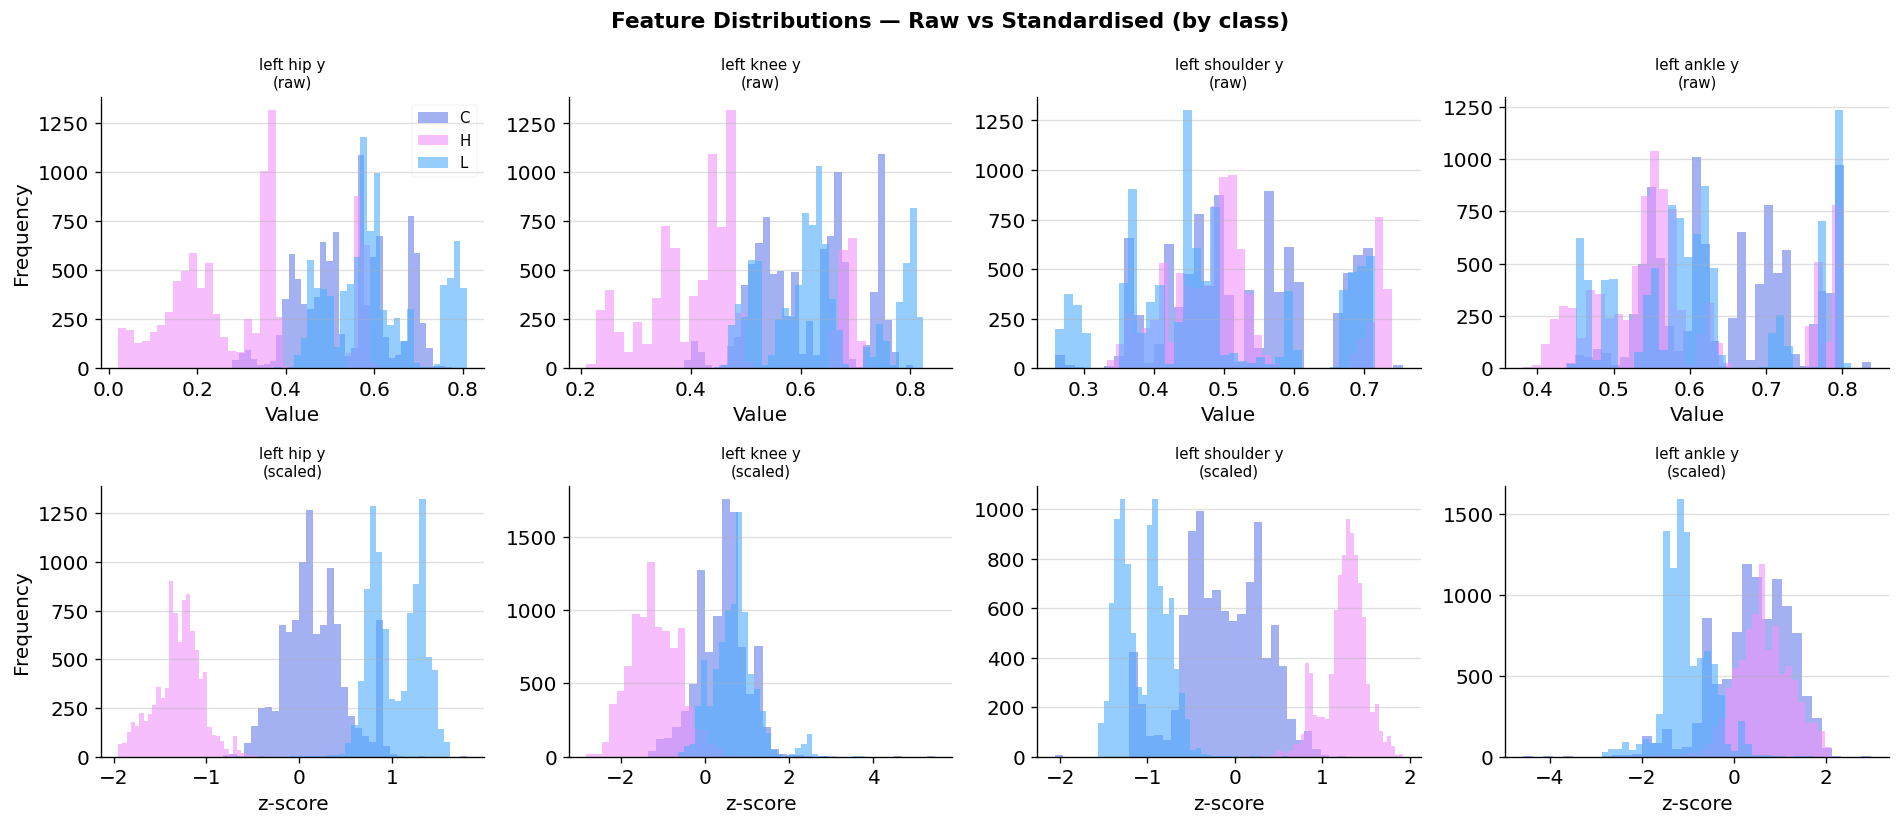

In [10]:
# ── Feature distributions: raw vs scaled (by class) ───────────────────────
sample_features = ['left_hip_y', 'left_knee_y', 'left_shoulder_y', 'left_ankle_y']
class_colors    = [C1, C2, C3]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Feature Distributions — Raw vs Standardised (by class)',
             fontsize=13, fontweight='bold')

for col, (ax_raw, ax_scl) in zip(sample_features, zip(axes[0], axes[1])):
    fidx = FEATURE_COLS.index(col)
    for lv, color in enumerate(class_colors):
        mask = y_train_np == lv
        name = le.classes_[lv]
        ax_raw.hist(train_df[FEATURE_COLS].values[mask, fidx],
                    bins=35, alpha=0.6, color=color, label=name, edgecolor='none')
        ax_scl.hist(X_train_np[mask, fidx],
                    bins=35, alpha=0.6, color=color, label=name, edgecolor='none')
    ax_raw.set_title(f'{col.replace("_"," ")}\n(raw)', fontsize=9)
    ax_scl.set_title(f'{col.replace("_"," ")}\n(scaled)', fontsize=9)
    ax_raw.set_xlabel('Value'); ax_scl.set_xlabel('z-score')
    ax_raw.grid(axis='y', alpha=0.4); ax_scl.grid(axis='y', alpha=0.4)

axes[0][0].set_ylabel('Frequency')
axes[1][0].set_ylabel('Frequency')
axes[0][0].legend(fontsize=9, framealpha=0.15)
plt.tight_layout()
plt.savefig('fig_03_feature_scaling.png', bbox_inches='tight')
plt.show()

## 5. Build PyG Dataset

Each row → a `torch_geometric.data.Data` object:
- `x`          : node feature matrix `[17, 4]`
- `edge_index` : `[2, 36]` (18 undirected edges × 2 directions)
- `y`          : scalar label `{0=C, 1=H, 2=L}`

In [11]:
def build_graph_dataset(X_np, y_np, edge_index):
    """
    Convert flat [N, 68] array into list of PyG Data objects.
    Reshape: [68] → [17 nodes, 4 features] per sample.
    """
    dataset = []
    for i in range(len(X_np)):
        x = torch.tensor(X_np[i].reshape(N_NODES, N_FEATS), dtype=torch.float)
        y = torch.tensor(y_np[i], dtype=torch.long)
        dataset.append(Data(x=x, edge_index=edge_index, y=y))
    return dataset


train_dataset = build_graph_dataset(X_train_np, y_train_np, EDGE_INDEX)
test_dataset  = build_graph_dataset(X_test_np,  y_test_np,  EDGE_INDEX)

BATCH_SIZE   = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

s = train_dataset[0]
print('Single graph object:')
print(f'  data.x          : {s.x.shape}    → [17 nodes, 4 features]')
print(f'  data.edge_index : {s.edge_index.shape}   → [2, {EDGE_INDEX.shape[1]} directed edges]')
print(f'  data.y          : {s.y.item()}   → (0=C, 1=H, 2=L)')
print(f'\nTrain batches : {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')

Single graph object:
  data.x          : torch.Size([17, 4])    → [17 nodes, 4 features]
  data.edge_index : torch.Size([2, 36])   → [2, 36 directed edges]
  data.y          : 0   → (0=C, 1=H, 2=L)

Train batches : 112
Test  batches : 3


## 6. Define the GNN Model — PlankGCN

Architecture:
```
Input node features [17, 4]
    ↓
GCNConv(4  → 64)  + BatchNorm + ReLU + Dropout
    ↓  (message passing over skeleton edges)
GCNConv(64 → 64)  + BatchNorm + ReLU + Dropout
    ↓  (message passing over skeleton edges)
GCNConv(64 → 32)  + BatchNorm + ReLU
    ↓
Flatten  [17 × 32 = 544]   ← preserves per-joint identity
    ↓
Linear(544 → 128) + ReLU + Dropout
Linear(128 → 64)  + ReLU + Dropout
Linear(64  → 3)             ← logits for C / H / L
```

> **Why flatten?** `global_mean_pool` averages all 17 node embeddings into one vector, destroying which joint is which. Flattening preserves all 17 node embeddings as separate signals — critical for detecting *where* in the body the error occurs.

In [12]:
class PlankGCN(nn.Module):
    """
    3-layer GCN for 3-class plank posture classification.
    Uses flatten (not global_mean_pool) to preserve node identity.
    """
    def __init__(self, in_feats=4, hidden=64, out_feats=32,
                 n_classes=3, dropout=0.4):
        super().__init__()
        self.out_feats = out_feats

        self.conv1 = GCNConv(in_feats, hidden)
        self.conv2 = GCNConv(hidden,   hidden)
        self.conv3 = GCNConv(hidden,   out_feats)

        self.bn1 = nn.BatchNorm1d(hidden)
        self.bn2 = nn.BatchNorm1d(hidden)
        self.bn3 = nn.BatchNorm1d(out_feats)

        # 17 nodes × 32 features = 544
        self.head = nn.Sequential(
            nn.Linear(N_NODES * out_feats, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )
        self.dropout = dropout

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn3(self.conv3(x, edge_index)))

        # Flatten — preserves all 17 node embeddings
        batch_size = batch.max().item() + 1
        x = x.view(batch_size, N_NODES * self.out_feats)  # [B, 544]

        return self.head(x)

    def embed(self, data):
        """Return flattened node embeddings before the classification head."""
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        batch_size = batch.max().item() + 1
        return x.view(batch_size, N_NODES * self.out_feats)


model      = PlankGCN(n_classes=N_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal trainable parameters: {total_params:,}')

PlankGCN(
  (conv1): GCNConv(4, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 32)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (head): Sequential(
    (0): Linear(in_features=544, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.4, inplace=False)
    (6): Linear(in_features=64, out_features=3, bias=True)
  )
)

Total trainable parameters: 85,091


## 7. Train the GNN

> **Important:** Both `train_epoch` and `evaluate` receive `device` as an explicit argument and call `batch.to(device)` inside — omitting this causes a CPU/CUDA mismatch that produces `NaN` loss.

In [13]:
# ── Training utilities ────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        batch = batch.to(device)           # ← move to same device as model
        optimizer.zero_grad()
        out  = model(batch)
        loss = criterion(out, batch.y)
        loss.backward()                    # backprop through all GCN layers
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        correct    += (out.argmax(1) == batch.y).sum().item()
        total      += batch.num_graphs
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_probs, all_labels = [], [], []
    for batch in loader:
        batch  = batch.to(device)          # ← move to same device as model
        out    = model(batch)
        loss   = criterion(out, batch.y)
        total_loss += loss.item() * batch.num_graphs
        probs  = F.softmax(out, dim=1)     # [B, 3] — all class probabilities
        pred   = out.argmax(dim=1)
        correct += (pred == batch.y).sum().item()
        total   += batch.num_graphs
        all_preds.extend(pred.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())   # list of [3] arrays
        all_labels.extend(batch.y.cpu().numpy())
    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_probs), np.array(all_labels))


def train_model(model, train_loader, test_loader, name='PlankGCN', epochs=100):
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}
    best_val_acc  = 0.0
    best_val_loss = float('inf')
    best_state    = None

    print(f'Training {name} for {epochs} epochs on {DEVICE}...')
    print(f'{"Epoch":>6} {"TrainLoss":>10} {"ValLoss":>10} {"TrainAcc":>10} {"ValAcc":>10}')
    print('─' * 55)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        va_loss, va_acc, _, _, _ = evaluate(model, test_loader, criterion, DEVICE)
        scheduler.step(va_loss)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc  = va_acc
            best_val_loss = va_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0 or epoch == 1:
            print(f'{epoch:>6} {tr_loss:>10.4f} {va_loss:>10.4f} '
                  f'{tr_acc*100:>9.2f}% {va_acc*100:>9.2f}%')

    model.load_state_dict(best_state)
    print('─' * 55)
    print(f'Best val accuracy : {best_val_acc*100:.2f}%')
    print(f'Best val loss     : {best_val_loss:.4f}')
    return history


print('Training utilities defined.')

Training utilities defined.


In [14]:
# ── Train PlankGCN ─────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

gcn_model   = PlankGCN(n_classes=N_CLASSES).to(DEVICE)
gcn_history = train_model(gcn_model, train_loader, test_loader, 'PlankGCN')

Training PlankGCN for 100 epochs on cuda...
 Epoch  TrainLoss    ValLoss   TrainAcc     ValAcc
───────────────────────────────────────────────────────
     1     0.1853     0.0834     93.30%     97.04%
    10     0.0124     0.0392     99.68%     99.01%
    20     0.0095     0.1061     99.78%     97.46%
    30     0.0067     0.1357     99.82%     97.32%
    40     0.0057     0.1279     99.86%     97.32%
    50     0.0049     0.1048     99.87%     97.46%
    60     0.0049     0.1088     99.88%     97.46%
    70     0.0038     0.1058     99.91%     97.46%
    80     0.0036     0.1093     99.92%     97.32%
    90     0.0034     0.1007     99.91%     97.32%
   100     0.0039     0.1166     99.92%     97.46%
───────────────────────────────────────────────────────
Best val accuracy : 99.44%
Best val loss     : 0.0310


## 8. Training Curves

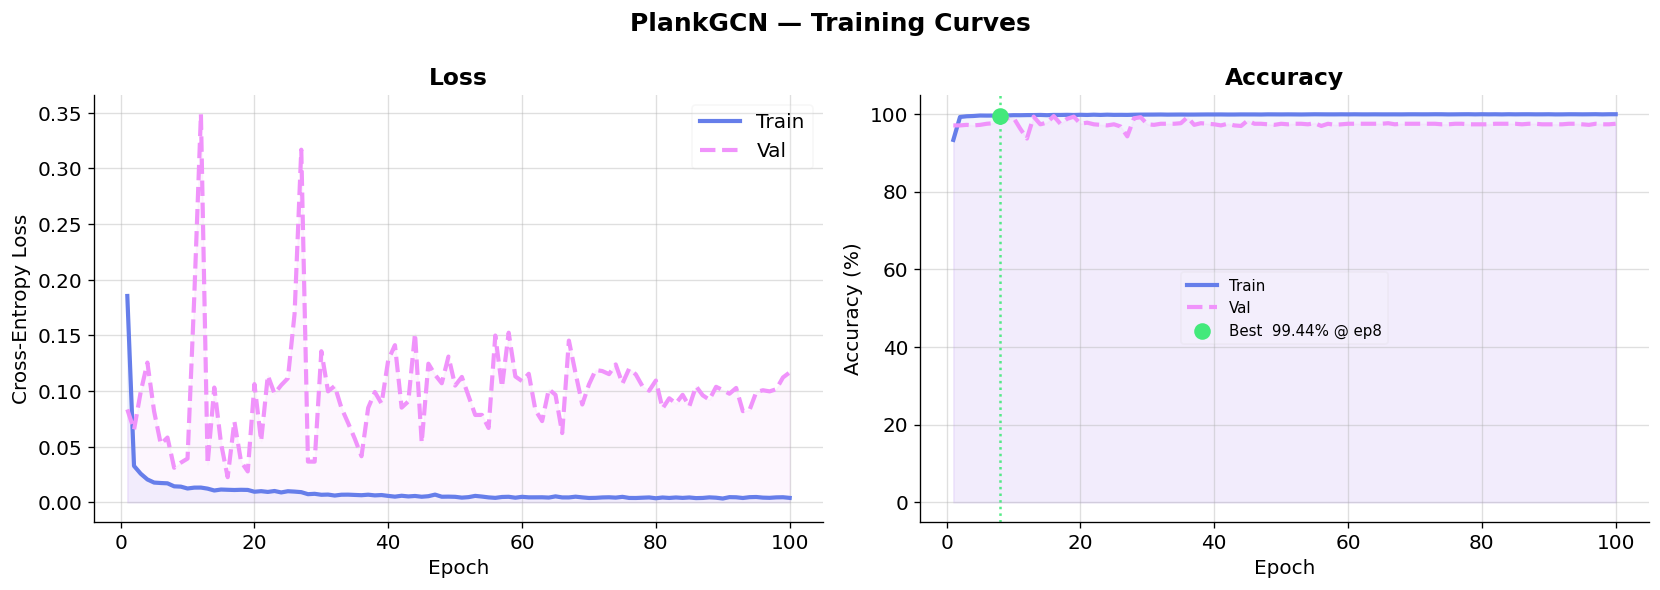

Saved: eval_01_training_curves.png


In [15]:
EPOCHS       = len(gcn_history['train_loss'])
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PlankGCN — Training Curves', fontsize=15, fontweight='bold')

# Loss
axes[0].plot(epochs_range, gcn_history['train_loss'], color=C1, lw=2.5, label='Train')
axes[0].plot(epochs_range, gcn_history['val_loss'],   color=C2, lw=2.5, ls='--', label='Val')
axes[0].fill_between(epochs_range, gcn_history['train_loss'], alpha=0.08, color=C1)
axes[0].fill_between(epochs_range, gcn_history['val_loss'],   alpha=0.08, color=C2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Loss', fontweight='bold')
axes[0].legend(framealpha=0.15); axes[0].grid(True, alpha=0.4)

# Accuracy
train_pct = [a * 100 for a in gcn_history['train_acc']]
val_pct   = [a * 100 for a in gcn_history['val_acc']]
axes[1].plot(epochs_range, train_pct, color=C1, lw=2.5, label='Train')
axes[1].plot(epochs_range, val_pct,   color=C2, lw=2.5, ls='--', label='Val')
axes[1].fill_between(epochs_range, train_pct, alpha=0.08, color=C1)
axes[1].fill_between(epochs_range, val_pct,   alpha=0.08, color=C2)

best_ep  = int(np.argmax(gcn_history['val_acc'])) + 1
best_val = max(val_pct)
axes[1].axvline(best_ep, color=C4, lw=1.5, ls=':', alpha=0.9)
axes[1].scatter(best_ep, best_val, color=C4, s=80, zorder=5,
               label=f'Best  {best_val:.2f}% @ ep{best_ep}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].legend(fontsize=9, framealpha=0.15); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('eval_01_training_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: eval_01_training_curves.png')

## 9. Save Model

In [16]:
# ── Save model weights and scaler ──────────────────────────────────────────
torch.save(gcn_model.state_dict(), 'plank_gcn.pth')
print('✅  Saved: plank_gcn.pth')

with open('plank_gcn_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('✅  Saved: plank_gcn_scaler.pkl')

print()
print('These two files are all you need for inference.')
print('Label encoding used:', dict(zip(le.classes_, le.transform(le.classes_))))

✅  Saved: plank_gcn.pth
✅  Saved: plank_gcn_scaler.pkl

These two files are all you need for inference.
Label encoding used: {'C': np.int64(0), 'H': np.int64(1), 'L': np.int64(2)}


## 10. Evaluation

In [17]:
from sklearn.metrics import precision_recall_fscore_support

# ── Collect predictions ───────────────────────────────────────────────────
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    for batch in loader:
        batch  = batch.to(device)
        out    = model(batch)
        probs  = F.softmax(out, dim=1)     # [B, 3]
        pred   = out.argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())   # list of [3]-arrays
        all_labels.extend(batch.y.cpu().numpy())
    return np.array(all_preds), np.array(all_probs), np.array(all_labels)


gcn_preds, gcn_probs, gcn_true = collect_predictions(gcn_model, test_loader, DEVICE)

# ── Scalar metrics (macro-averaged for multiclass) ────────────────────────
gcn_metrics = {
    'Accuracy' : accuracy_score(gcn_true, gcn_preds),
    'F1 (macro)'  : f1_score(gcn_true, gcn_preds, average='macro'),
    'Precision(macro)': precision_score(gcn_true, gcn_preds, average='macro'),
    'Recall(macro)'   : recall_score(gcn_true, gcn_preds, average='macro'),
}

print('═' * 45)
print('  PlankGCN — Test Set Performance')
print('═' * 45)
for k, v in gcn_metrics.items():
    bar = '█' * int(v * 20)
    print(f'  {k:20s}  {v*100:6.2f}%  {bar}')
print('═' * 45)
print()
print(classification_report(gcn_true, gcn_preds, target_names=le.classes_))

═════════════════════════════════════════════
  PlankGCN — Test Set Performance
═════════════════════════════════════════════
  Accuracy               99.44%  ███████████████████
  F1 (macro)             99.44%  ███████████████████
  Precision(macro)       99.44%  ███████████████████
  Recall(macro)          99.44%  ███████████████████
═════════════════════════════════════════════

              precision    recall  f1-score   support

           C       0.98      1.00      0.99       234
           H       1.00      0.99      1.00       241
           L       1.00      0.99      1.00       235

    accuracy                           0.99       710
   macro avg       0.99      0.99      0.99       710
weighted avg       0.99      0.99      0.99       710



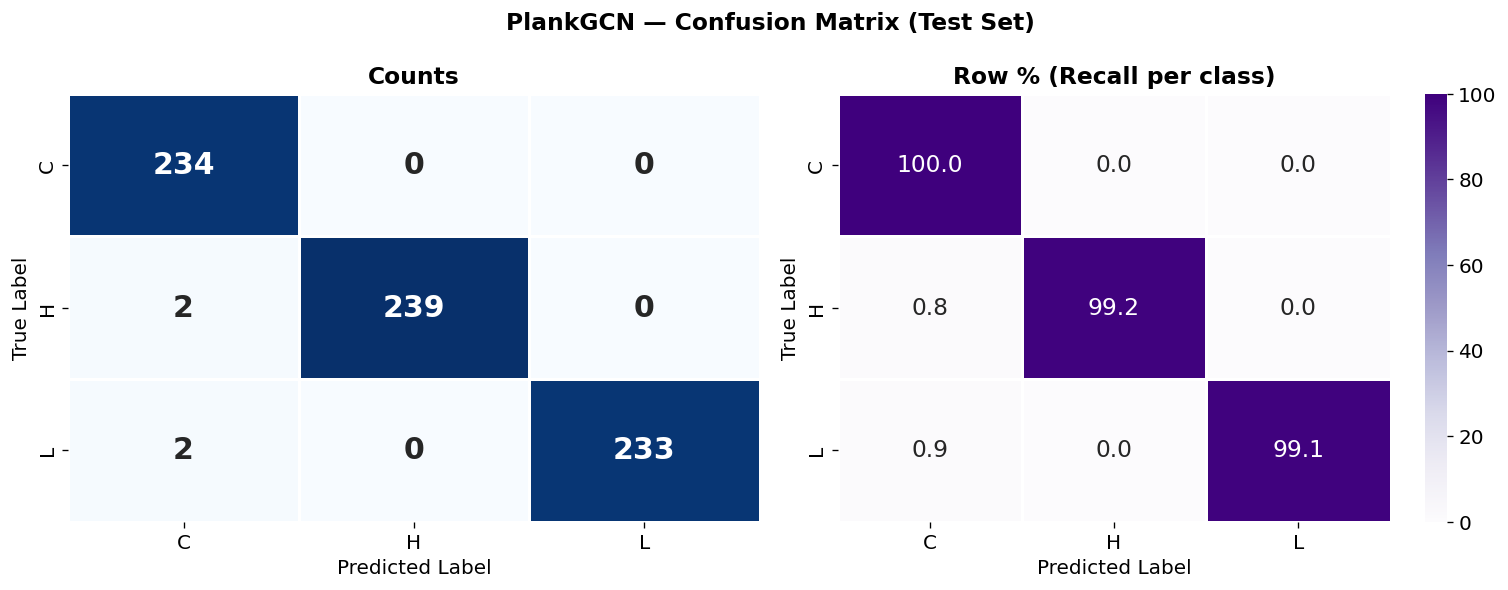

Saved: eval_02_confusion_matrix.png


In [18]:
# ── Confusion matrix ───────────────────────────────────────────────────────
cm     = confusion_matrix(gcn_true, gcn_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('PlankGCN — Confusion Matrix (Test Set)',
             fontsize=14, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=1.5, ax=axes[0], cbar=False,
            annot_kws={'size': 18, 'weight': 'bold'})
axes[0].set_title('Counts', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=1.5, ax=axes[1], cbar=True,
            annot_kws={'size': 14})
axes[1].set_title('Row % (Recall per class)', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('eval_02_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: eval_02_confusion_matrix.png')

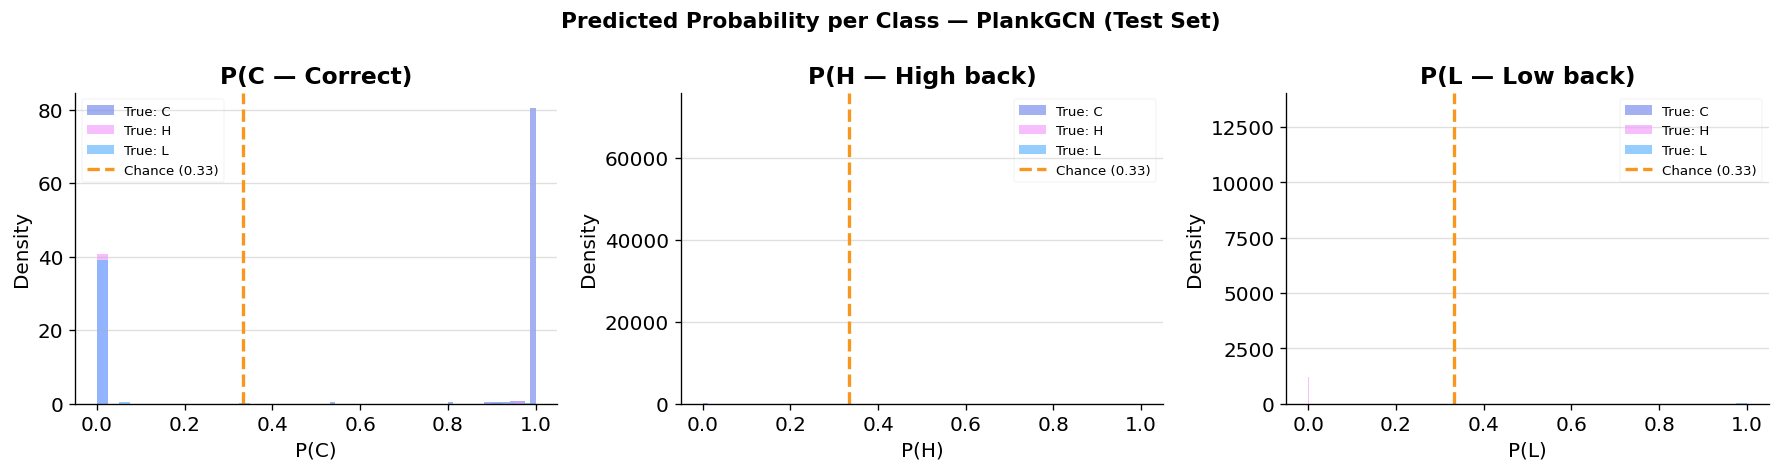

Saved: eval_03_prob_distributions.png


In [19]:
# ── Per-class probability distributions ───────────────────────────────────
# gcn_probs shape: [N_samples, 3]
class_names_full = {0: 'C — Correct', 1: 'H — High back', 2: 'L — Low back'}
row_colors       = [C1, C2, C3]

fig, axes = plt.subplots(1, N_CLASSES, figsize=(15, 4))
fig.suptitle('Predicted Probability per Class — PlankGCN (Test Set)',
             fontsize=13, fontweight='bold')

for cls_idx in range(N_CLASSES):
    ax = axes[cls_idx]
    for true_cls, color in enumerate(row_colors):
        mask = gcn_true == true_cls
        ax.hist(gcn_probs[mask, cls_idx], bins=40, alpha=0.6,
                color=color, label=f'True: {le.classes_[true_cls]}',
                edgecolor='none', density=True)
    ax.axvline(1/N_CLASSES, color='#f7971e', lw=2, ls='--',
               label=f'Chance ({1/N_CLASSES:.2f})')
    ax.set_xlabel(f'P({le.classes_[cls_idx]})')
    ax.set_ylabel('Density')
    ax.set_title(f'P({class_names_full[cls_idx]})', fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.15)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('eval_03_prob_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: eval_03_prob_distributions.png')

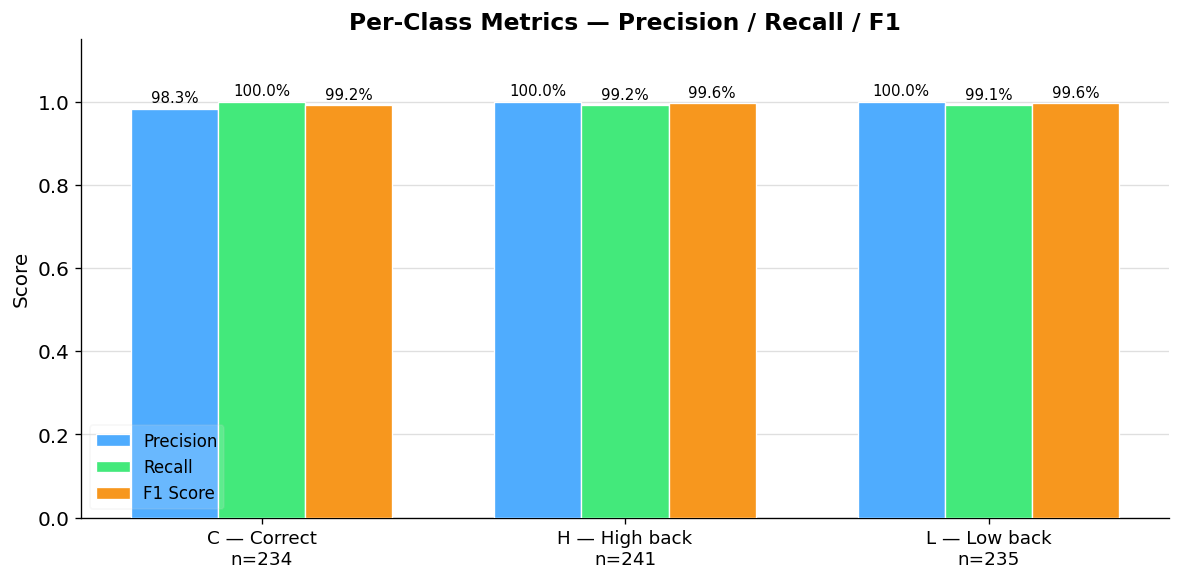

Saved: eval_04_per_class_metrics.png


In [20]:
# ── Per-class Precision / Recall / F1 bar chart ───────────────────────────
prec, rec, f1, support = precision_recall_fscore_support(
    gcn_true, gcn_preds, labels=list(range(N_CLASSES)))

x      = np.arange(N_CLASSES)
w      = 0.24
colors = ['#4facfe', '#43e97b', '#f7971e']

fig, ax = plt.subplots(figsize=(10, 5))
bars_p = ax.bar(x - w,  prec, w, color=colors[0], edgecolor='white',
                linewidth=0.8, label='Precision', zorder=3)
bars_r = ax.bar(x,      rec,  w, color=colors[1], edgecolor='white',
                linewidth=0.8, label='Recall',    zorder=3)
bars_f = ax.bar(x + w,  f1,   w, color=colors[2], edgecolor='white',
                linewidth=0.8, label='F1 Score',  zorder=3)

for bars in [bars_p, bars_r, bars_f]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.008,
                f'{bar.get_height()*100:.1f}%',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'{class_names_full[i]}\nn={support[i]}'
                    for i in range(N_CLASSES)], fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Per-Class Metrics — Precision / Recall / F1', fontweight='bold')
ax.legend(fontsize=10, framealpha=0.15)
ax.grid(axis='y', alpha=0.4, zorder=0)

plt.tight_layout()
plt.savefig('eval_04_per_class_metrics.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: eval_04_per_class_metrics.png')

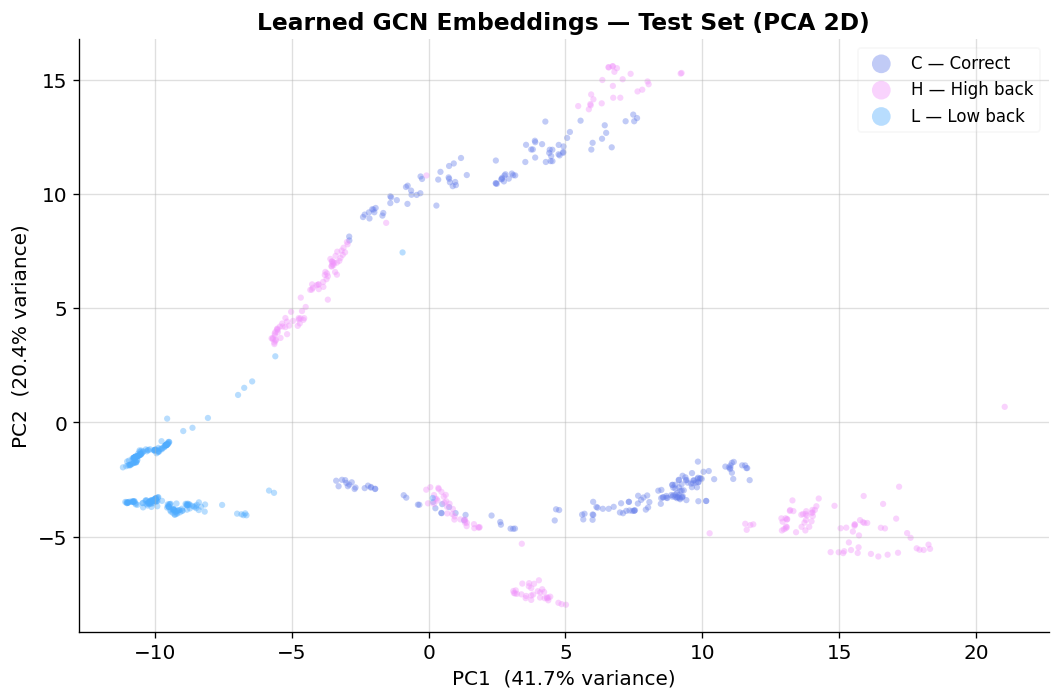

Embedding dim : 544  (17 nodes × 32 features)
Saved: eval_05_embeddings_pca.png


In [21]:
# ── Learned embedding space (PCA) ─────────────────────────────────────────
@torch.no_grad()
def get_embeddings(model, loader, device):
    model.eval()
    embs, labels = [], []
    for batch in loader:
        batch = batch.to(device)
        embs.append(model.embed(batch).cpu().numpy())
        labels.append(batch.y.cpu().numpy())
    return np.vstack(embs), np.concatenate(labels)


embs, emb_labels = get_embeddings(gcn_model, test_loader, DEVICE)

pca    = PCA(n_components=2, random_state=RANDOM_STATE)
emb_2d = pca.fit_transform(embs)

fig, ax = plt.subplots(figsize=(9, 6))
for lv, color in enumerate(row_colors):
    mask = emb_labels == lv
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=color, alpha=0.4, s=14, edgecolors='none',
               label=class_names_full[lv])

ax.set_xlabel(f'PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Learned GCN Embeddings — Test Set (PCA 2D)', fontweight='bold')
ax.legend(markerscale=3, fontsize=10, framealpha=0.15)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('eval_05_embeddings_pca.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Embedding dim : {embs.shape[1]}  (17 nodes × 32 features)')
print('Saved: eval_05_embeddings_pca.png')

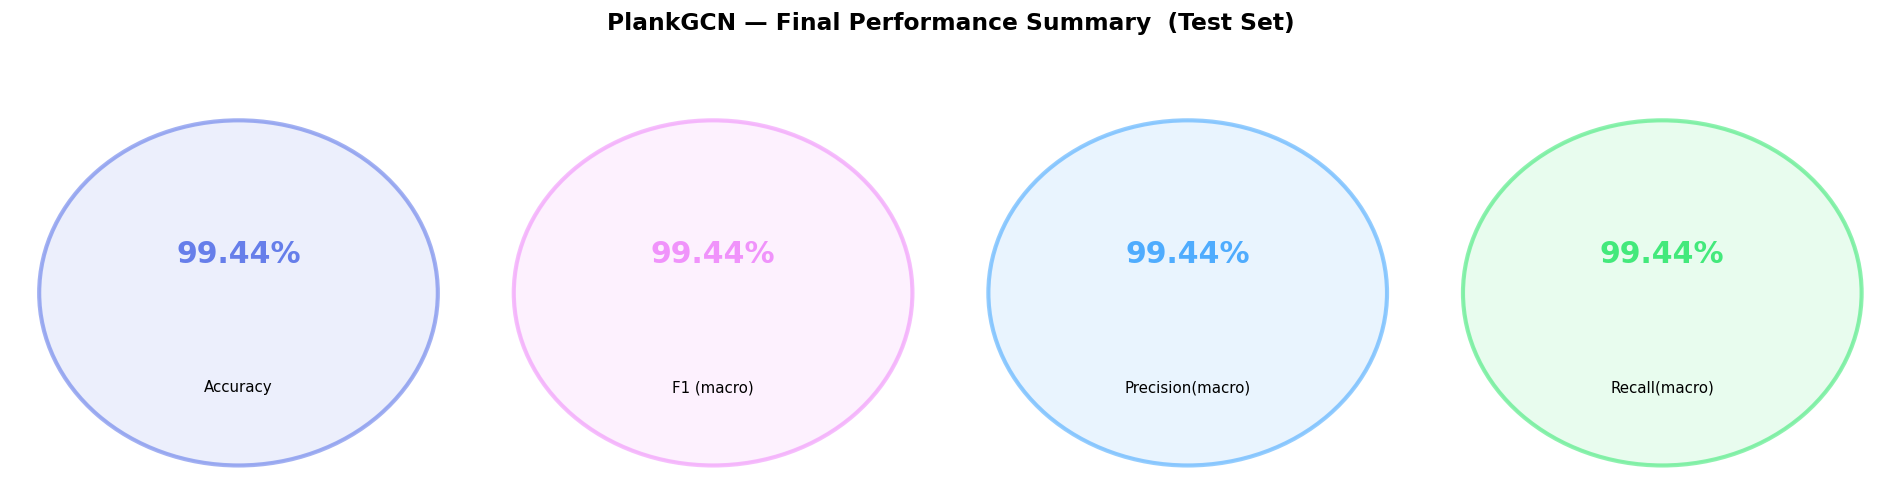


═════════════════════════════════════════════
  FINAL RESULTS — PlankGCN
═════════════════════════════════════════════
  Accuracy               :  99.4366%
  F1 (macro)             :  99.4362%
  Precision(macro)       :  99.4398%
  Recall(macro)          :  99.4397%
═════════════════════════════════════════════
Saved: eval_06_final_dashboard.png


In [22]:
# ── Final results dashboard ────────────────────────────────────────────────
metric_names  = list(gcn_metrics.keys())
metric_vals   = list(gcn_metrics.values())
accent_colors = [C1, C2, C3, C4]

fig, axes = plt.subplots(1, len(metric_names), figsize=(16, 4))
fig.suptitle('PlankGCN — Final Performance Summary  (Test Set)',
             fontsize=14, fontweight='bold', y=1.04)

for ax, name, val, color in zip(axes, metric_names, metric_vals, accent_colors):
    ax.add_patch(plt.Circle((0.5, 0.5), 0.44, color=color, alpha=0.12))
    ax.add_patch(plt.Circle((0.5, 0.5), 0.44, fill=False,
                             edgecolor=color, linewidth=2.5, alpha=0.6))
    ax.text(0.5, 0.60, f'{val*100:.2f}%',
            ha='center', va='center', fontsize=18,
            fontweight='bold', color=color)
    ax.text(0.5, 0.26, name,
            ha='center', va='center', fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

plt.tight_layout()
plt.savefig('eval_06_final_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n' + '═'*45)
print('  FINAL RESULTS — PlankGCN')
print('═'*45)
for k, v in gcn_metrics.items():
    print(f'  {k:22s} :  {v*100:.4f}%')
print('═'*45)
print('Saved: eval_06_final_dashboard.png')